# S09: Context Graph Expansion

This talktorial introduces **hierarchical context expansion** as a principled way to
control the generality–specificity trade-off in reaction-center templates.
By expanding the reaction center with progressively larger chemical neighbourhoods
(radii *r* = 0 … 5), the template library becomes either more general (small *r*,
high coverage) or more specific (large *r*, high precision).
We first build the core BFS expansion by hand, then scale it with SynKit's
`HierContext`, and evaluate multi-radius libraries on a real dataset.

## Aim of this talktorial

**Learning outcomes** — by the end of this notebook you will be able to:

- Define the *r*-hop context neighbourhood N_r(C) on an ITS graph and explain
  its role in the DPO span L ← K → R.
- Implement BFS-based context expansion from scratch and verify it matches
  SynKit's `HierContext`.
- Extract multi-radius template libraries for a single rule family and visualise
  how the context grows.
- Evaluate forward-prediction coverage (recall), recognition (precision), and F1
  at each radius and plot the trade-off curve.
- Apply a decision workflow to choose a practical radius for a given dataset.

## Outline

- [0. Setup & data](#0-setup--data)
- [1. What is context?](#1-what-is-context)
  - [1.1 The reaction center — recap](#11-the-reaction-center--recap)
  - [1.2 Defining the r-hop context](#12-defining-the-r-hop-context)
  - [1.3 Implement expand_context from scratch](#13-implement-expand_context-from-scratch)
  - [1.4 Visualise r = 0, 1, 2 on one ITS](#14-visualise-r--0-1-2-on-one-its)
  - [1.5 The context subgraph as the DPO K-graph](#15-the-context-subgraph-as-the-dpo-k-graph)
- [2. Rule family deep-dive — radii 0–5](#2-rule-family-deep-dive--radii-05)
  - [2.1 Pick the working family](#21-pick-the-working-family)
  - [2.2 Extract multi-radius templates with HierContext](#22-extract-multi-radius-templates-with-hiercontext)
  - [2.3 Template count vs. radius](#23-template-count-vs-radius)
  - [2.4 Visual tour — K-graphs at r = 0, 1, 2](#24-visual-tour--k-graphs-at-r--0-1-2)
  - [2.5 Multi-radius evaluation loop](#25-multi-radius-evaluation-loop)
  - [2.6 Trade-off curve](#26-trade-off-curve)
- [3. Generalising — family-dependent optima](#3-generalising--family-dependent-optima)
- [4. Choosing a radius in practice](#4-choosing-a-radius-in-practice)
- [5. Quiz](#5-quiz)
- [6. Discussion](#6-discussion)

## 0. Setup & data

In [1]:
%matplotlib inline
import rdkit
import pandas as pd
import networkx as nx
from pathlib import Path
import importlib.metadata as _m
from synkit.IO import load_database
import logging


def _silence():
    logging.disable(logging.CRITICAL)


_silence()

print("RDKit    :", rdkit.__version__)
print("NetworkX :", nx.__version__)
print("SynKit   :", _m.version('synkit'))

DATA_PATH = Path("data") / "smart.json.gz"
data = pd.DataFrame(load_database(DATA_PATH)[:2000])
print(f"\nDataset : {data.shape[0]} reactions  ·  columns: {list(data.columns)}")
data.head(3)

RDKit    : 2025.09.3
NetworkX : 3.6.1
SynKit   : 1.3.2

Dataset : 2000 reactions  ·  columns: ['R-id', 'smart']


,R-id,smart
0,7873,[CH3:1][C:2]([CH3:3])([CH3:4])[O:5][C:6](=[O:7...
1,42468,[Br:1][CH2:2][c:3]1[cH:4][cH:6][c:7]([Br:8])[c...
2,24541,[CH3:1][N:2]([CH3:3])[CH2:4][CH2:5][NH:6][H:7]...


**Split the dataset**

We use an 80 / 20 train / test split with the same seed as S08 so that results
are comparable. The training split is used to build template libraries at every
radius; the test split is reserved for evaluation.

In [2]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(data, test_size=0.2, random_state=42)
print(f"Train : {len(train_df)}  |  Test : {len(test_df)}")

Train : 1600  |  Test : 400


**Build the rule library — ITS, WL hash, and clustering**

We reuse the exact pipeline from S07/S08:

1. Convert each training reaction to its full ITS graph and to its
   reaction-center (RC) graph.
2. Compute a WL hash of each RC for fast grouping.
3. Cluster with `GraphCluster` to identify rule families.

This is shown quickly here; refer to S07 for a step-by-step explanation.

In [3]:
from synkit.IO import rsmi_to_its
from synkit.Graph.Feature.wl_hash import WLHash
from synkit.Graph.Matcher.graph_cluster import GraphCluster
from synkit.Chem.Reaction.standardize import Standardize

_wl = WLHash()
train = train_df.to_dict("records")
for v in train:
    v["ITS"] = rsmi_to_its(v["smart"], core=False)  # full ITS (all atoms)
    v["RC"] = rsmi_to_its(v["smart"], core=True)  # reaction-center only
    v["wl"] = _wl.weisfeiler_lehman_graph_hash(v["RC"])

_cls = GraphCluster()
cluster = _cls.fit(train, rule_key="RC", attribute_key="wl")

_df_cls = pd.DataFrame(cluster)
print("Rule family sizes (top 8):")
print(_df_cls["class"].value_counts().head(8).to_string())

Rule family sizes (top 8):
class
6     281
0     208
4     111
17    105
5      80
9      75
12     62
2      57


**Standardise the test set**

We remove atom mapping from test reactions so that the predictor never sees the
ground-truth correspondence. Standardisation also normalises ring perception and
aromaticity, which is required for fair chemical comparison.

In [4]:
_std = Standardize()
test = test_df.to_dict("records")
for v in test:
    _rsmi = _std.fit(v["smart"], remove_aam=True)
    v["r"], v["p"] = _rsmi.split(">>")
    v["rsmi"] = _rsmi

print(f"Test set standardised: {len(test)} entries")
print("Example — reactant :", test[0]["r"][:60], "…")

Test set standardised: 400 entries
Example — reactant : Brc1ccc(OCC2Cn3c(nc4ccccc43)O2)cc1.Cn1nccc1B1OC(C)(C)C(C)(C) …


## 1. What is context?

The *reaction center* captures the minimum subgraph that changes in a reaction.
**Context expansion** augments that minimal representation by pulling in the
chemical neighbourhood around it.  Before using SynKit's ready-made tool, we
build the expansion by hand so the mechanism is fully transparent.

### 1.1 The reaction center — recap

From S04: an edge (u, v) in the ITS graph belongs to the **reaction center**
E_rc if its bond orders on the reactant and product sides differ:

$$E_{\text{rc}} = \{(u,v) \in E \mid b_r(u,v) \neq b_p(u,v)\}$$

The **reaction-center nodes** V_rc are all endpoints of edges in E_rc.
At radius *r* = 0, V_rc is the starting seed for context expansion.

In [5]:
def reaction_center_nodes(its: nx.Graph) -> set:
    """Return atoms incident to any bond that changes between reactant and product."""
    rc = set()
    for u, v, d in its.edges(data=True):
        br, bp = d.get("order", (0.0, 0.0))
        if abs(float(br) - float(bp)) > 1e-6:
            rc.update([u, v])
    return rc


# Quick check on the first training reaction
_its_ex = cluster[0]["ITS"]
_rc_ex = reaction_center_nodes(_its_ex)
print(
    f"ITS has {_its_ex.number_of_nodes()} nodes, " f"{_its_ex.number_of_edges()} edges"
)
print(f"Reaction-center nodes: {sorted(_rc_ex)}")

ITS has 35 nodes, 41 edges
Reaction-center nodes: [15, 16, 33, 34]


### 1.2 Defining the r-hop context

**Definition.** Let C ⊆ V be the reaction-center atoms of an ITS graph G.
The *r-hop context* is:

$$N_r(C) = \{ v \in V \mid \text{dist}(v,\, C) \leq r \}$$

where dist(v, C) = min_{c ∈ C} d_G(v, c) is the shortest-path distance in G.

The **context subgraph** K_r is the subgraph of G induced by N_r(C).

| r | What is included |
|---|---|
| 0 | Only the atoms that directly break or form bonds |
| 1 | Those atoms + all their immediate ITS neighbours |
| 2 | r=1 context + one more shell of neighbours |
| k | All atoms within k hops of any reaction-center atom |

At r = 0, K_r is the smallest possible rule (maximum generality).
Each additional hop adds chemical context, increasing specificity.

### 1.3 Implement `expand_context` from scratch

**Q1.** Before reading the solution below, try to implement `expand_context(its, r)`
yourself: given an ITS graph and a radius *r*, return the induced subgraph of all nodes
within *r* hops of the reaction center.

*Hint*: start with a frontier set equal to the reaction-center nodes.
Each iteration, extend the frontier by one shell of neighbours and merge into
the accumulated set.

In [6]:
def expand_context(its: nx.Graph, r: int) -> nx.Graph:
    """Return the ITS subgraph within r hops of the reaction center."""
    seed = reaction_center_nodes(its)
    frontier = set(seed)
    for _ in range(r):
        next_shell = set()
        for v in frontier:
            next_shell.update(its.neighbors(v))
        frontier = next_shell - seed  # only brand-new nodes
        seed |= frontier
    return its.subgraph(seed).copy()


# Verify: r=0 should give back exactly the reaction-center subgraph
_ctx0 = expand_context(_its_ex, 0)
_ctx1 = expand_context(_its_ex, 1)
_ctx2 = expand_context(_its_ex, 2)
print(f"r=0 → {_ctx0.number_of_nodes()} nodes")
print(f"r=1 → {_ctx1.number_of_nodes()} nodes")
print(f"r=2 → {_ctx2.number_of_nodes()} nodes")
print(f"Full ITS → {_its_ex.number_of_nodes()} nodes")

r=0 → 4 nodes
r=1 → 7 nodes
r=2 → 10 nodes
Full ITS → 35 nodes


### 1.4 Visualise r = 0, 1, 2 on one ITS

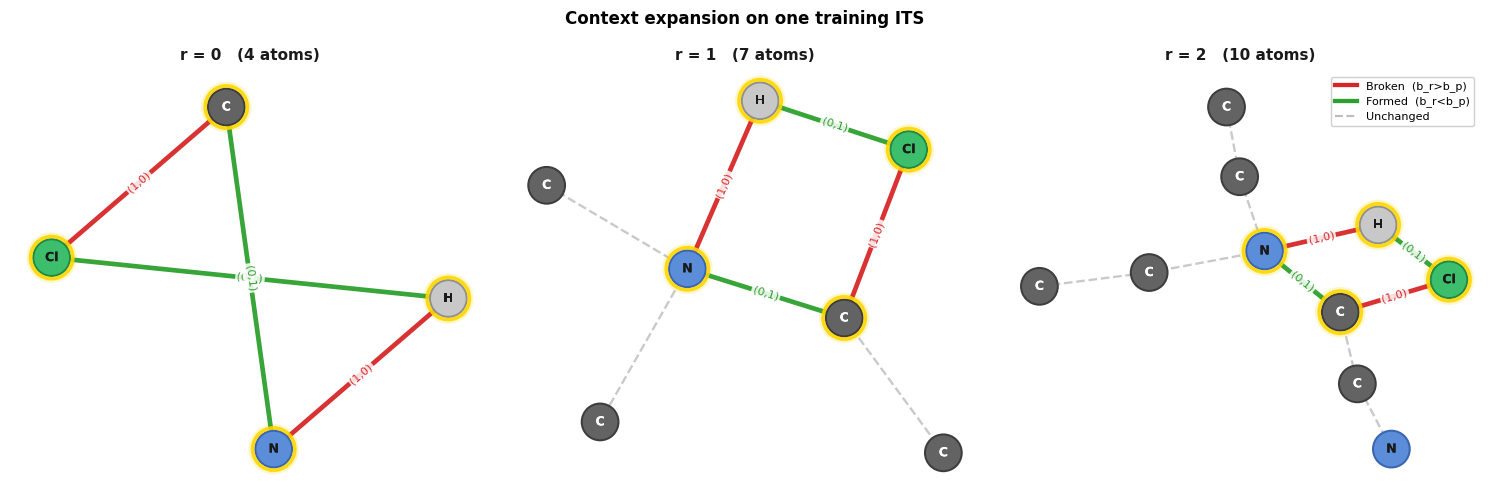

Gold rings mark reaction-center atoms (changed bonds).
Each +1 radius adds one shell of chemical neighbours.


In [7]:
import matplotlib.pyplot as plt
from synedu.Utils.its_vis import visualize_its

fig, axes = plt.subplots(1, 3, figsize=(15, 5), facecolor="white")
fig.suptitle("Context expansion on one training ITS", fontsize=12, fontweight="bold")

for k, ax in enumerate(axes):
    ctx = expand_context(_its_ex, k)
    visualize_its(
        ctx,
        ax=ax,
        title=f"r = {k}   ({ctx.number_of_nodes()} atoms)",
        show_legend=(k == 2),
        show_edge_labels=True,
    )

plt.tight_layout()
plt.show()
print("Gold rings mark reaction-center atoms (changed bonds).")
print("Each +1 radius adds one shell of chemical neighbours.")

### 1.5 The context subgraph as the DPO K-graph

In S05 we defined a **DPO span** L ← K → R where K is the *interface*
subgraph — the part of the rule that is not rewritten.

The context subgraph K_r built above is exactly this interface graph:

- **L** = the reactant-side view of K_r (with b_r bond orders)
- **R** = the product-side view of K_r (with b_p bond orders)
- **K** = the shared atoms and unchanged bonds

A larger K_r carries more chemical context → the rule pattern-matches fewer
(but more precisely chosen) substrates → higher precision, lower coverage.

## 2. Rule family deep-dive — radii 0–5

We now focus on a **single rule family** — the largest cluster — and study
how the template library and prediction quality change as we vary *r* from 0 to 5.

### 2.1 Pick the working family

Working family: class 6
Training reactions in this family: 281


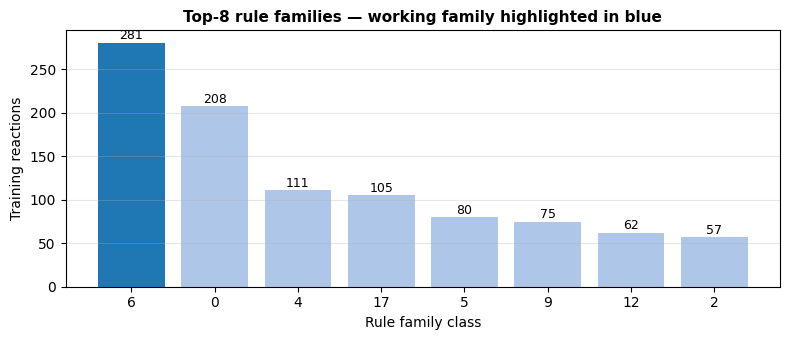

In [8]:
TOP_CLASS = int(_df_cls["class"].value_counts().idxmax())
family_train = [v for v in cluster if v["class"] == TOP_CLASS]

print(f"Working family: class {TOP_CLASS}")
print(f"Training reactions in this family: {len(family_train)}")

# Show the 5 most common rule families as a bar chart
import matplotlib.pyplot as plt

_vc = _df_cls["class"].value_counts().head(8)
fig, ax = plt.subplots(figsize=(8, 3.5), facecolor="white")
bars = ax.bar(
    _vc.index.astype(str),
    _vc.values,
    color=["#1f77b4" if c == TOP_CLASS else "#aec7e8" for c in _vc.index],
)
ax.set_xlabel("Rule family class", fontsize=10)
ax.set_ylabel("Training reactions", fontsize=10)
ax.set_title(
    "Top-8 rule families — working family highlighted in blue",
    fontsize=11,
    fontweight="bold",
)
for bar, val in zip(bars, _vc.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        val + 0.5,
        str(val),
        ha="center",
        va="bottom",
        fontsize=9,
    )
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

Let us look at a few representative reactions from this family to confirm
they share the same reaction-center topology.

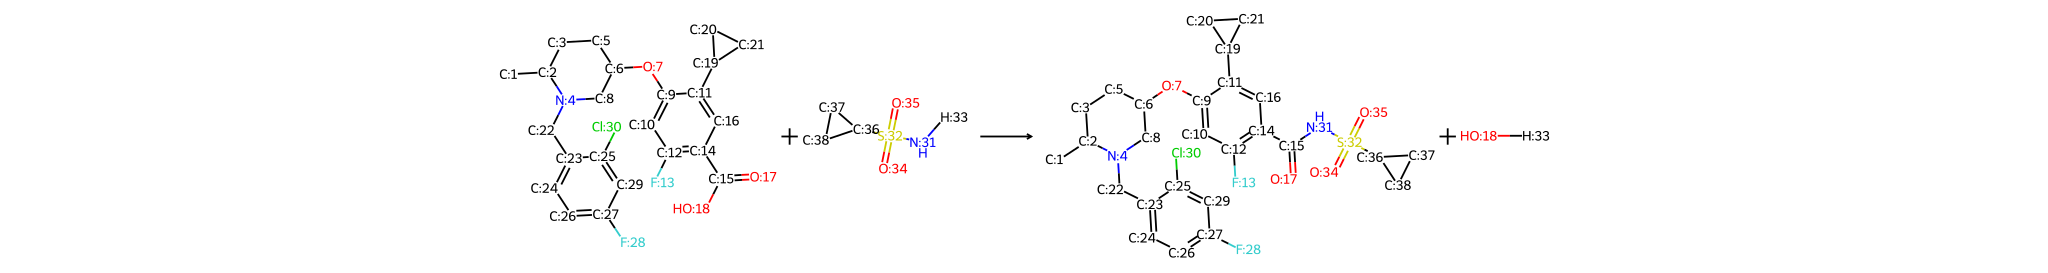

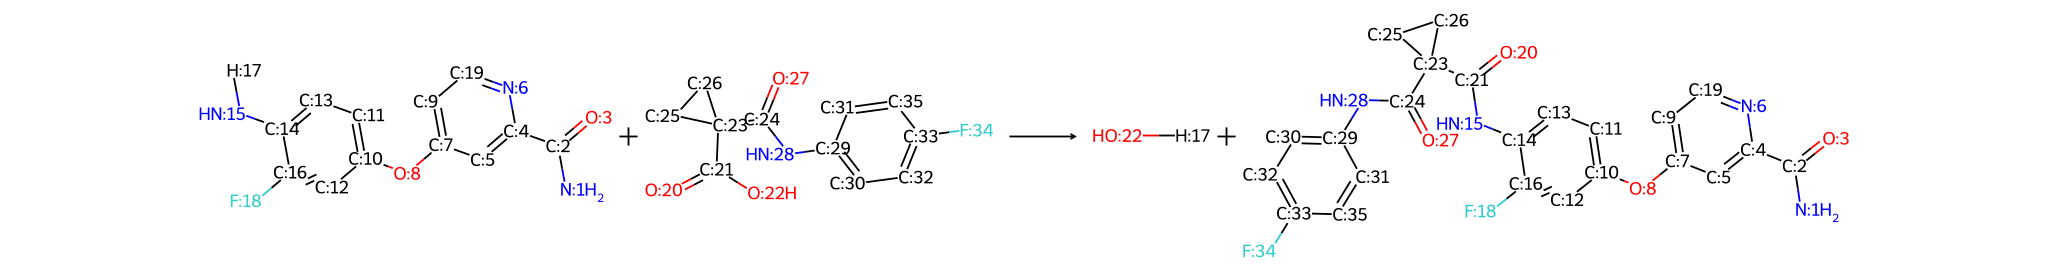

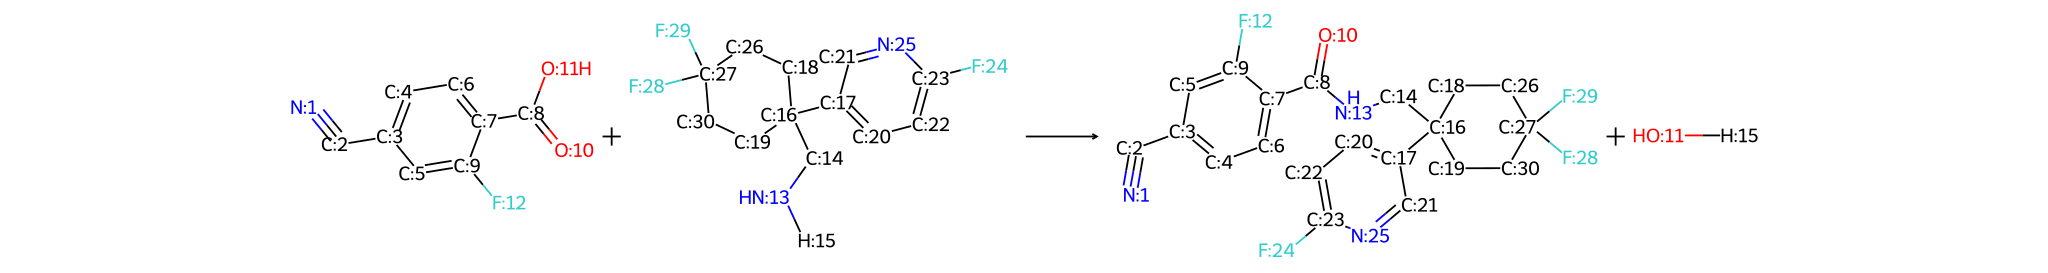

In [9]:
from synedu.Utils.rxn_vis import visualize_reaction
from IPython.display import SVG, display

_samples = family_train[:3]
for i, v in enumerate(_samples):
    display(
        SVG(
            visualize_reaction(
                v["smart"],
                svg=True,
                legend=f"Family {TOP_CLASS} — example {i+1}",
                highlight_changes=True,
            )
        )
    )

### 2.2 Extract multi-radius templates with `HierContext`

`HierContext` does exactly what our hand-built `expand_context` does,
but applied to every training reaction simultaneously and with automatic
deduplication at each radius level.

```
HierContext(max_radius=5).fit(family_train, its_key="ITS")
    → (demo,  templates)
       demo        : updated training records with hierarchical cluster indices
       templates   : list of length max_radius+1
                     templates[r] = list of unique K-graphs at radius r
                     each entry: {"K": nx.Graph, "class": int, ...}
```

In [10]:
from synkit.Graph.Context.hier_context import HierContext

_hc = HierContext(max_radius=5)
_demo, _templates = _hc.fit(family_train, "ITS")

print(f"Radius levels returned: {len(_templates)}")
for r, tlist in enumerate(_templates):
    print(f"  r = {r} → {len(tlist):3d} unique templates")

Radius levels returned: 6
  r = 0 →   1 unique templates
  r = 1 →  30 unique templates
  r = 2 → 156 unique templates
  r = 3 → 261 unique templates
  r = 4 → 274 unique templates
  r = 5 → 278 unique templates


### 2.3 Template count vs. radius

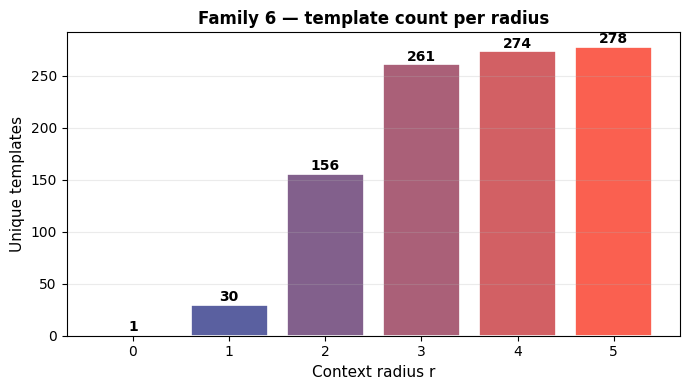


Key observation:
 r=0 → 1 template   (all reactions share the same reaction center)
 r=1 → many more    (immediate neighbourhood already differentiates reactions)
 r≥3 → near-plateau (family is nearly fully disambiguated)


In [11]:
import matplotlib.pyplot as plt
import numpy as np

_radii = list(range(len(_templates)))
_counts = [len(tl) for tl in _templates]

fig, ax = plt.subplots(figsize=(7, 4), facecolor="white")
bars = ax.bar(
    _radii,
    _counts,
    color=[f"#{int(50+r*40):02x}60{int(180-r*20):02x}" for r in _radii],
    edgecolor="white",
    linewidth=1.2,
)
for bar, cnt in zip(bars, _counts):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        cnt + 0.3,
        str(cnt),
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
    )
ax.set_xlabel("Context radius r", fontsize=11)
ax.set_ylabel("Unique templates", fontsize=11)
ax.set_title(
    f"Family {TOP_CLASS} — template count per radius", fontsize=12, fontweight="bold"
)
ax.set_xticks(_radii)
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

print("\nKey observation:")
print(" r=0 → 1 template   (all reactions share the same reaction center)")
print(" r=1 → many more    (immediate neighbourhood already differentiates reactions)")
print(" r≥3 → near-plateau (family is nearly fully disambiguated)")

### 2.4 Visual tour — K-graphs at r = 0, 1, 2

We draw one representative K-graph per radius using `visualize_its`
(which handles ITS-style edge attributes automatically).

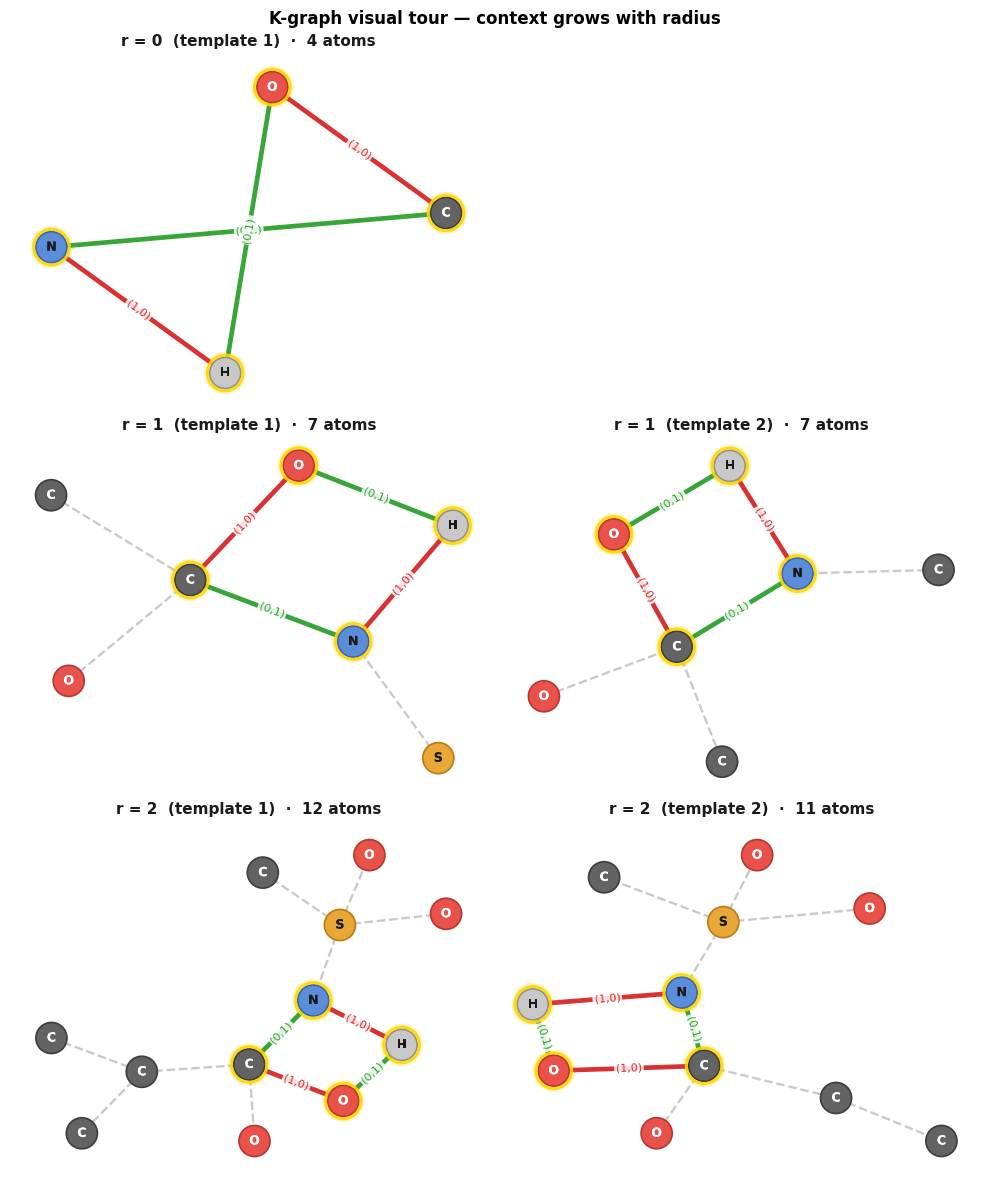

In [12]:
import matplotlib.pyplot as plt
from synedu.Utils.its_vis import visualize_its

_show_radii = [0, 1, 2]
_n_show = 2  # templates per radius

fig, axes = plt.subplots(
    len(_show_radii),
    _n_show,
    figsize=(_n_show * 5, len(_show_radii) * 4),
    facecolor="white",
)
fig.suptitle(
    "K-graph visual tour — context grows with radius", fontsize=12, fontweight="bold"
)

for row, r in enumerate(_show_radii):
    for col in range(_n_show):
        ax = axes[row][col]
        tlist = _templates[r]
        if col < len(tlist):
            K = tlist[col]["K"]
            visualize_its(
                K,
                ax=ax,
                title=f"r = {r}  (template {col+1})  ·  {K.number_of_nodes()} atoms",
                show_legend=False,
                show_edge_labels=True,
                node_size=500,
            )
        else:
            ax.set_axis_off()

plt.tight_layout()
plt.show()

### 2.5 Multi-radius evaluation loop

We now apply each radius's template library to the test set and measure:

| Metric | What it captures |
|---|---|
| **Coverage** (recall) | Fraction of test reactions where the ground truth appears in the candidate set |
| **Recognition** (precision) | Fraction of *unique* generated candidates that match the ground truth |
| **F1** | Harmonic mean of Coverage and Recognition |

We use the same `SynReactor` and `_compute_metrics` tools introduced in S08.

In [13]:
# Re-import S08 evaluation tools with a brief explanation
from synkit.Synthesis.Reactor.syn_reactor import SynReactor
from synkit.Synthesis.Metrics._base import _compute_metrics

# SynReactor  — applies one DPO template to one substrate SMILES
#               .smarts_list returns generated reaction SMARTS
# _compute_metrics(data, key_gt, key_pred) — computes Coverage/Recognition/F1

_std2 = Standardize()


def _apply_templates(entries, template_graphs, *, n_entries=25):
    """Apply a list of K-graph templates to up to n_entries test reactions."""
    subset = entries[:n_entries]
    for v in subset:
        fw = []
        for K in template_graphs:
            try:
                reactor = SynReactor(
                    substrate=v["r"],
                    template=K,
                    explicit_h=True,
                    implicit_temp=False,
                    automorphism=True,
                )
                fw.extend(reactor.smarts_list)
            except Exception:
                pass
        # standardise and deduplicate
        clean = []
        for s in fw:
            try:
                c = _std2.fit(s)
                if c:
                    clean.append(c)
            except Exception:
                pass
        v["fw_clean"] = list(set(clean))
    return subset


print("Evaluation helpers ready.")

Evaluation helpers ready.


In [14]:
import time

_eval_results = []
_N_TEST = 25  # test entries used per radius (keep notebook fast)

for r, tlist in enumerate(_templates):
    t0 = time.time()
    tmpl_graphs = [t["K"] for t in tlist]

    # work on fresh copies so we don't accumulate fw_clean across iterations
    import copy

    _entries = copy.deepcopy(test[:_N_TEST])
    _entries = _apply_templates(_entries, tmpl_graphs, n_entries=_N_TEST)

    elapsed = time.time() - t0
    m = _compute_metrics(_entries, "rsmi", "fw_clean", beta=1)

    _eval_results.append(
        {
            "r": r,
            "n_templates": len(tlist),
            "elapsed": round(elapsed, 2),
            "Coverage": round(m.get("Coverage", 0.0), 3),
            "Recognition": round(m.get("Recognition", 0.0), 3),
            "F1": round(m.get("F1_score", 0.0), 3),
        }
    )
    print(
        f"r={r}  templates={len(tlist):3d}  "
        f"Cov={_eval_results[-1]['Coverage']:.3f}  "
        f"Rec={_eval_results[-1]['Recognition']:.3f}  "
        f"F1={_eval_results[-1]['F1']:.3f}  "
        f"({elapsed:.1f}s)"
    )

_eval_df = pd.DataFrame(_eval_results)
print("\nDone.")

r=0  templates=  1  Cov=0.120  Rec=0.047  F1=0.067  (0.2s)
r=1  templates= 30  Cov=0.080  Rec=0.040  F1=0.053  (2.3s)
r=2  templates=156  Cov=0.080  Rec=0.060  F1=0.069  (11.4s)
r=3  templates=261  Cov=0.040  Rec=0.040  F1=0.040  (20.0s)
r=4  templates=274  Cov=0.040  Rec=0.040  F1=0.040  (23.0s)
r=5  templates=278  Cov=0.040  Rec=0.040  F1=0.040  (23.8s)

Done.


### 2.6 Trade-off curve

The two-panel figure below is the central diagnostic of S09:

- **Left panel** — Coverage vs. Recognition scatter, one point per radius.
  Moving right and up is better; the best operating point is the point
  closest to the top-right corner.
- **Right panel** — Template count and wall-clock time vs. radius.
  These capture the *cost* of higher specificity.

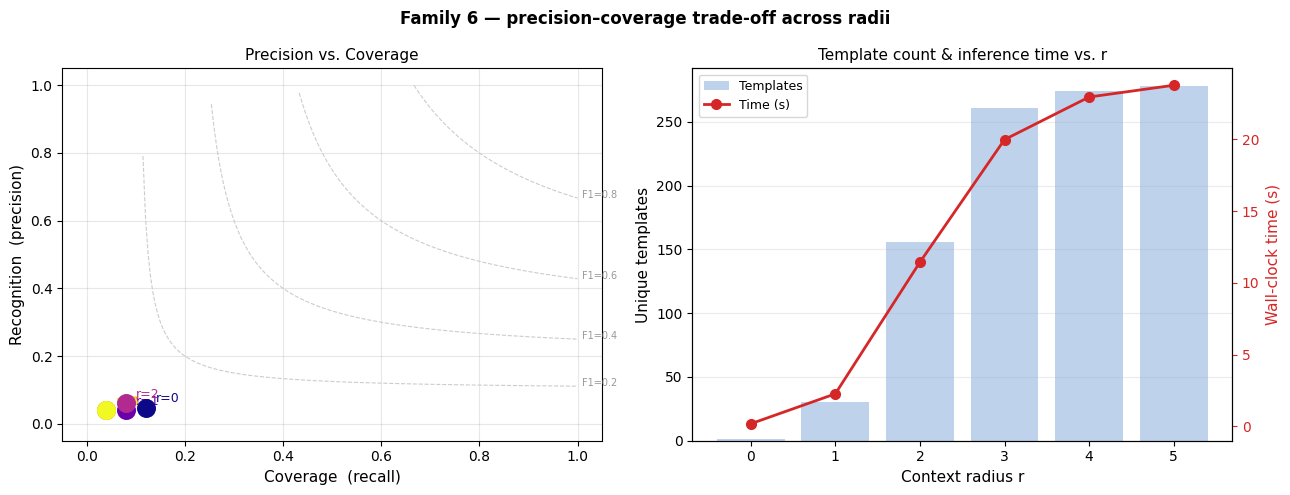

 r  n_templates  Coverage  Recognition    F1  elapsed
 0            1      0.12        0.047 0.067     0.17
 1           30      0.08        0.040 0.053     2.26
 2          156      0.08        0.060 0.069    11.44
 3          261      0.04        0.040 0.040    19.99
 4          274      0.04        0.040 0.040    22.96
 5          278      0.04        0.040 0.040    23.78


In [15]:
import matplotlib.pyplot as plt
import numpy as np

fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(13, 5), facecolor="white")
fig.suptitle(
    f"Family {TOP_CLASS} — precision–coverage trade-off across radii",
    fontsize=12,
    fontweight="bold",
)

# ── Left: Coverage vs Recognition scatter ──
_cmap = plt.cm.plasma
_norm = plt.Normalize(0, max(_eval_df["r"]))
for _, row in _eval_df.iterrows():
    c = _cmap(_norm(row["r"]))
    ax_left.scatter(row["Coverage"], row["Recognition"], color=c, s=160, zorder=5)
    ax_left.annotate(
        f"r={int(row['r'])}",
        (row["Coverage"], row["Recognition"]),
        textcoords="offset points",
        xytext=(7, 4),
        fontsize=9,
        color=c,
    )

ax_left.set_xlabel("Coverage  (recall)", fontsize=11)
ax_left.set_ylabel("Recognition  (precision)", fontsize=11)
ax_left.set_title("Precision vs. Coverage", fontsize=11)
ax_left.grid(alpha=0.3)
ax_left.set_xlim(-0.05, 1.05)
ax_left.set_ylim(-0.05, 1.05)

# diagonal iso-F1 lines
for f1_val in [0.2, 0.4, 0.6, 0.8]:
    xs = np.linspace(0.01, 1.0, 200)
    ys = f1_val * xs / (2 * xs - f1_val)
    mask = (ys > 0) & (ys <= 1)
    ax_left.plot(xs[mask], ys[mask], "--", color="#cccccc", lw=0.8)
    ax_left.text(
        xs[mask][-1] + 0.01, ys[mask][-1], f"F1={f1_val}", fontsize=7, color="#999999"
    )

# ── Right: template count + time vs radius ──
_ax2 = ax_right.twinx()
ax_right.bar(
    _eval_df["r"],
    _eval_df["n_templates"],
    color="#aec7e8",
    alpha=0.8,
    label="Templates",
)
_ax2.plot(
    _eval_df["r"],
    _eval_df["elapsed"],
    "o-",
    color="#d62728",
    lw=2,
    ms=7,
    label="Time (s)",
)

ax_right.set_xlabel("Context radius r", fontsize=11)
ax_right.set_ylabel("Unique templates", fontsize=11)
_ax2.set_ylabel("Wall-clock time (s)", fontsize=11, color="#d62728")
_ax2.tick_params(axis="y", colors="#d62728")
ax_right.set_title("Template count & inference time vs. r", fontsize=11)
ax_right.set_xticks(_eval_df["r"])

lines_a, labels_a = ax_right.get_legend_handles_labels()
lines_b, labels_b = _ax2.get_legend_handles_labels()
ax_right.legend(lines_a + lines_b, labels_a + labels_b, fontsize=9)
ax_right.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

# Table summary
print(
    _eval_df[
        ["r", "n_templates", "Coverage", "Recognition", "F1", "elapsed"]
    ].to_string(index=False)
)

## 3. Generalising — family-dependent optima

The optimal radius found for our working family may not apply universally.
Different rule families have different symmetry profiles, ring environments,
and neighbour diversity, so the coverage–precision trade-off curve will differ.

The code below repeats the evaluation across the **top 3 families** at radii
r = 0, 1, 2 and assembles the results into a **heatmap** (family × radius → F1).
Running it confirms that the best radius is family-dependent.

In [16]:
import copy

_TOP_N = 3  # number of families to evaluate
_R_MAX = 3  # max radius for multi-family study (keep runtime short)
_N_T_MF = 15  # test entries per family

_top_classes = list(_df_cls["class"].value_counts().head(_TOP_N).index)

_heatmap = {}  # {class_id: {r: F1}}

for cls_id in _top_classes:
    _fam_train = [v for v in cluster if v["class"] == cls_id]
    _hc_mf = HierContext(max_radius=_R_MAX)
    _, _tmpl_mf = _hc_mf.fit(_fam_train, "ITS")

    _heatmap[cls_id] = {}
    for r in range(_R_MAX + 1):
        _graphs_mf = [t["K"] for t in _tmpl_mf[r]]
        _entries_mf = copy.deepcopy(test[:_N_T_MF])
        _entries_mf = _apply_templates(_entries_mf, _graphs_mf, n_entries=_N_T_MF)
        _m_mf = _compute_metrics(_entries_mf, "rsmi", "fw_clean", beta=1)
        _heatmap[cls_id][r] = round(_m_mf.get("F1_score", 0.0), 3)

    print(
        f"Family {cls_id}: r0-r{_R_MAX} F1 =",
        [_heatmap[cls_id][r] for r in range(_R_MAX + 1)],
    )

Family 6: r0-r3 F1 = [0.033, 0.044, 0.067, 0.067]
Family 0: r0-r3 F1 = [0.182, 0.182, 0.067, 0.067]
Family 4: r0-r3 F1 = [0.044, 0.044, 0.044, 0.044]


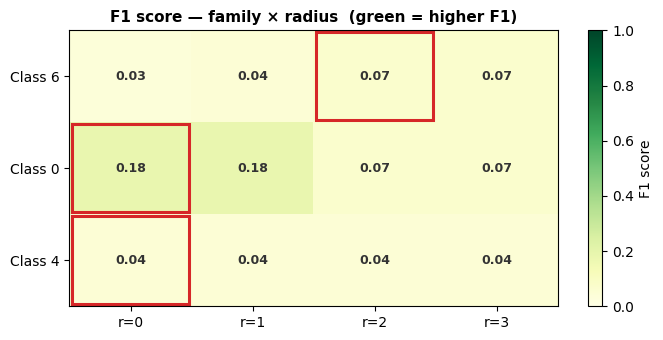

Red border = best radius for each family.
Key observation: the optimal radius differs across families.


In [17]:
import matplotlib.pyplot as plt
import numpy as np

_cls_ids = _top_classes
_rs = list(range(_R_MAX + 1))
_mat = np.array([[_heatmap[c][r] for r in _rs] for c in _cls_ids])

fig, ax = plt.subplots(figsize=(7, 3.5), facecolor="white")
im = ax.imshow(_mat, cmap="YlGn", vmin=0, vmax=1, aspect="auto")

ax.set_xticks(_rs)
ax.set_xticklabels([f"r={r}" for r in _rs], fontsize=10)
ax.set_yticks(range(len(_cls_ids)))
ax.set_yticklabels([f"Class {c}" for c in _cls_ids], fontsize=10)
ax.set_title(
    "F1 score — family × radius  (green = higher F1)", fontsize=11, fontweight="bold"
)
plt.colorbar(im, ax=ax, label="F1 score")

for i, c in enumerate(_cls_ids):
    for j, r in enumerate(_rs):
        ax.text(
            j,
            i,
            f"{_mat[i,j]:.2f}",
            ha="center",
            va="center",
            fontsize=9,
            fontweight="bold",
            color="white" if _mat[i, j] > 0.6 else "#333333",
        )

# highlight best-r per family
for i in range(len(_cls_ids)):
    best_j = int(np.argmax(_mat[i]))
    ax.add_patch(
        plt.Rectangle(
            (best_j - 0.48, i - 0.48),
            0.96,
            0.96,
            fill=False,
            edgecolor="#d62728",
            lw=2.2,
        )
    )

plt.tight_layout()
plt.show()
print("Red border = best radius for each family.")
print("Key observation: the optimal radius differs across families.")

## 4. Choosing a radius in practice

The trade-off curves and heatmap together inform a practical decision workflow.
The schematic below summarises the main decision points.

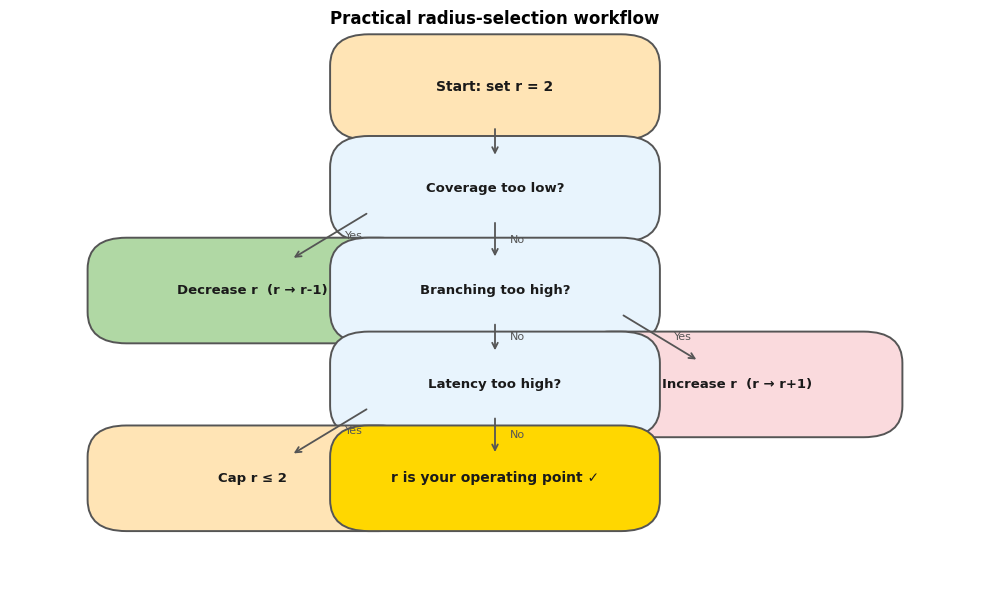

In [18]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(10, 6), facecolor="white")
ax.set_xlim(0, 10)
ax.set_ylim(0, 7)
ax.set_axis_off()
ax.set_title("Practical radius-selection workflow", fontsize=12, fontweight="bold")

_BOX_KW = dict(boxstyle="round,pad=0.4", lw=1.4)


def _box(ax, x, y, text, color="#AEC6E8", fontsize=9.5, w=2.6, h=0.55):
    ax.add_patch(
        mpatches.FancyBboxPatch(
            (x - w / 2, y - h / 2), w, h, fc=color, ec="#555", **_BOX_KW
        )
    )
    ax.text(
        x,
        y,
        text,
        ha="center",
        va="center",
        fontsize=fontsize,
        fontweight="bold",
        color="#1a1a1a",
        wrap=True,
    )


def _arrow(ax, x1, y1, x2, y2, label=""):
    ax.annotate(
        "",
        xy=(x2, y2),
        xytext=(x1, y1),
        arrowprops=dict(arrowstyle="->", color="#555", lw=1.3),
    )
    if label:
        mx, my = (x1 + x2) / 2, (y1 + y2) / 2
        ax.text(mx + 0.15, my, label, fontsize=8, color="#555", ha="left", va="center")


# Start
_box(ax, 5, 6.3, "Start: set r = 2", color="#FFE4B5", fontsize=10)
# Decision 1
_box(ax, 5, 5.0, "Coverage too low?", color="#E8F4FD")
_arrow(ax, 5, 5.8, 5, 5.4)
# Yes → decrease r
_box(ax, 2.5, 3.7, "Decrease r  (r → r-1)", color="#B0D8A4")
_arrow(ax, 3.7, 4.7, 2.9, 4.1, "Yes")
# No → decision 2
_box(ax, 5, 3.7, "Branching too high?", color="#E8F4FD")
_arrow(ax, 5, 4.6, 5, 4.1, "No")
# Yes → increase r
_box(ax, 7.5, 2.5, "Increase r  (r → r+1)", color="#FADADD")
_arrow(ax, 6.3, 3.4, 7.1, 2.8, "Yes")
# No → decision 3
_box(ax, 5, 2.5, "Latency too high?", color="#E8F4FD")
_arrow(ax, 5, 3.3, 5, 2.9, "No")
# Yes → cap at 2
_box(ax, 2.5, 1.3, "Cap r ≤ 2", color="#FFE4B5")
_arrow(ax, 3.7, 2.2, 2.9, 1.6, "Yes")
# No → done
_box(ax, 5, 1.3, "r is your operating point ✓", color="#FFD700", fontsize=10)
_arrow(ax, 5, 2.1, 5, 1.6, "No")

plt.tight_layout()
plt.show()

**Practical guidelines (summary)**

| Situation | Action |
|---|---|
| Need to identify core transformation types | Start at r = 0 |
| Symmetry-induced ambiguous matches | Increase to r = 1 |
| Retrosynthesis planning (high precision) | r = 2 or 3 |
| Coverage drops sharply above some r | Normalise charges / tautomers upstream |
| Latency is a hard constraint | r ≤ 2 |
| F1 plateaus | You are in the saturation regime — larger r gives no gain |

**Never tune the radius on the test set.** Use a validation split for radius
selection and reserve the test set for final reporting only.

**Q2.** At r = 0, two reactions that differ only in a remote substituent
(e.g. –F vs. –Cl on the meta position of an aromatic ring) are treated as
**identical** templates because the reaction center is the same.

Give a concrete example where this causes an incorrect forward prediction.
What is the *minimum* r needed to distinguish the two reactions, assuming the
substituent is located exactly 3 bonds from the nearest reaction-center atom?

## 5. Quiz

### Q1 — Template count saturation

If you increase r from 2 to 3 for a given family, do you always get *more*
unique templates? Explain why or why not, referring to the deduplication step
performed by `HierContext`.

*Hint*: think about what happens when every training reaction in the family
shares exactly the same 3-hop neighbourhood.

---

### Q2 — When does r = 0 fail? (see §4)

---

### Q3 — Ring-aware context (implementation)

Implement `ring_aware_context(its, r)`: identical to `expand_context` but,
once any atom of a ring is included in the context, **all** atoms of that ring
are also included (even if they are farther than r hops away).

```python
def ring_aware_context(its: nx.Graph, r: int) -> nx.Graph:
    ...
```

*Hint*: use `nx.cycle_basis(its)` to enumerate rings.
After building the r-hop context with ordinary BFS, iterate over all rings:
if any ring member is already in the context, add the whole ring.

In [19]:
# Q3 — Solution (try it yourself first!)
def ring_aware_context(its: nx.Graph, r: int) -> nx.Graph:
    """r-hop context, extended to include any ring that overlaps the context."""
    ctx_nodes = set(expand_context(its, r).nodes())

    rings = nx.cycle_basis(its)
    changed = True
    while changed:  # iterate until no ring is partially included
        changed = False
        for ring in rings:
            ring_set = set(ring)
            if ring_set & ctx_nodes and not ring_set <= ctx_nodes:
                ctx_nodes |= ring_set
                changed = True

    return its.subgraph(ctx_nodes).copy()


# Quick test
_ctx_ring = ring_aware_context(_its_ex, 1)
_ctx_plain = expand_context(_its_ex, 1)
print(f"plain  r=1 : {_ctx_plain.number_of_nodes()} nodes")
print(f"ring-aware : {_ctx_ring.number_of_nodes()} nodes")

plain  r=1 : 7 nodes
ring-aware : 10 nodes


## 6. Discussion

### Key takeaways

**The generality–specificity trade-off is fundamental.**
Any pattern-matching system over structured data faces it. The graph-rewriting
formalism makes it explicit, controllable, and measurable via standard
information-retrieval metrics.

**The optimal radius is family-dependent.**
Families whose reactions share a highly symmetric neighbourhood saturate
at r = 1.  Families involving ring-fused or stereocentre-bearing contexts
may need r = 3 or higher.

**`HierContext` is just principled BFS at scale.**
The hand-built `expand_context` in §1 and the SynKit `HierContext` are
algorithmically equivalent; the latter adds deduplication and multi-level
indexing across an entire training corpus.

**What this series does not cover** — and where to go next:

| Extension | Notes |
|---|---|
| Stereocentre-aware templates | Requires encoding CIP descriptors in node attributes |
| Tautomer normalisation | Pre-process with RDKit's MolStandardize before extracting ITS |
| Learning-based candidate ranking | Train a graph neural network to rank candidates from large *r* |
| End-to-end retrosynthesis | Use templates as moves in an MCTS search tree |
| Reaction-centre definition | Replace bond-order change with charge, radical, or isotope change |

### The full pipeline in one sentence

SMILES → ITS → reaction center → WL hash → cluster by family →
`HierContext` per family → multi-radius template library → `SynReactor` →
`_compute_metrics` → choose *r*.

This is the conceptual endpoint of the SynEdu series.